In [290]:
import matplotlib.pyplot as plt
import math

In [223]:
def linspace(start, end, step=1):
    xs = [start]
    while start < end:
        start += step
        xs.append(start)
    return xs

def chi2_pdf(x, k):
    if x <= 0:
        return 0
    numerator = math.exp(-x / 2) * x ** (k / 2 - 1)
    denominator = 2 ** (k / 2) * math.gamma(k / 2)
    return numerator / denominator

def inv_chi2_cdf(alpha, k):
    # this should be correct up to at least two decimal places.
    x = 0
    cdf = 0
    while cdf < alpha:
        y = chi2_pdf(x, k)
        cdf += y * 1e-4
        x += 1e-4

    return x

In [224]:
xs = linspace(-10, 10, 1e-4)

In [232]:
ys = [chi2_pdf(x, 3) for x in xs]

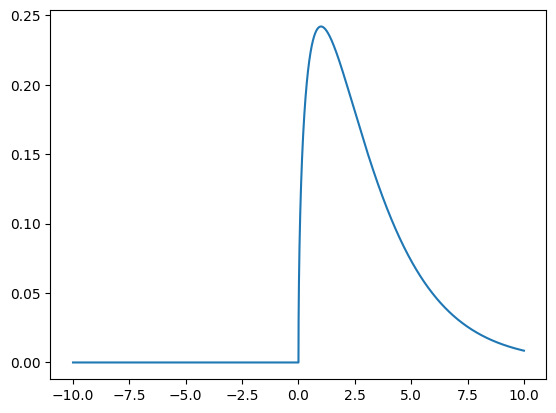

In [234]:
plt.plot(xs, ys)

## Random Number Generation using LCG

In [15]:
MULTIPLIER = 5
STEP = 5
LIMIT = 100

In [34]:
def lcg_rng(x, multiplier, step, limit):
    return (multiplier * x + step) % limit

class RNG:
    def __init__(self, multiplier=5, step=5, limit=100, seed=41):
        self.multiplier = multiplier
        self.step = step
        self.limit = limit
        self.seed = seed

    def generate(self, size=10, low=0, high=10):
        numbers = []
        x = self.seed
        for _ in range(size):
            number = lcg_rng(x, self.multiplier, self.step, self.limit)
            x = number
            numbers.append(number)

        # normalize
        numbers = [num / self.limit for num in numbers]
        return [num * (high - low) + low for num in numbers]

In [122]:
rng = RNG()

In [128]:
SIZE = 10

In [129]:
y = rng.generate(size=SIZE, high=3)
y

[0.30000000000000004,
 1.6500000000000001,
 2.4000000000000004,
 0.15000000000000002,
 0.8999999999999999,
 1.6500000000000001,
 2.4000000000000004,
 0.15000000000000002,
 0.8999999999999999,
 1.6500000000000001]

In [124]:
n_bins = 3

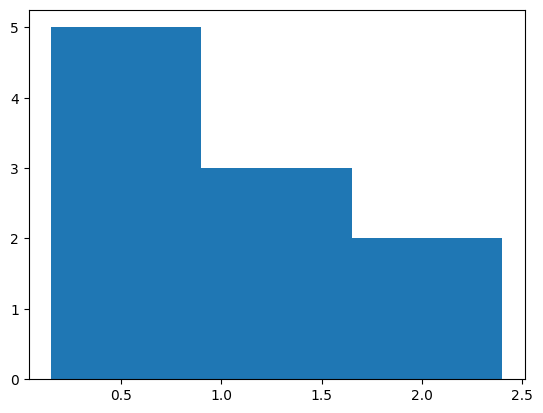

In [126]:
act_freq = plt.hist(y, 3)[0]

In [130]:
exp_freq = SIZE / 3

3.3333333333333335

## Tests

### Uniformity and Independence Tests

In [331]:
def chi_statistic(freqs, expected_freq):
    return sum([(freq - expected_freq) ** 2 / expected_freq for freq in freqs])

def test(size, bins, limit, multiplier=MULTIPLIER, step=STEP, seed=41):
    rng = RNG(multiplier=multiplier, step=step, limit=limit, seed=seed)

    y = rng.generate(size=size, low=0, high=limit)
    bins = bins

    # graph_test(y, bins=limit)
    # graph test
    freqs = plt.hist(y, bins=bins)[0]
    plt.xlabel("random number")
    plt.ylabel("frequency")
    plt.savefig("/home/arktetra/Labs/Sim/lab-3/images/rnd.png", dpi=600, bbox_inches="tight")
    expected_freq = size / bins
    expected_chi = chi_statistic(freqs, expected_freq)
    actual_chi = inv_chi2_cdf(1 - 0.05, bins - 1)
    if expected_chi < actual_chi:
        print(f"Chi-square Test: Passed successfully, since {expected_chi:.4f} < {actual_chi:.4f}")
    else:
        print(f"Chi-square Test: Failed, since {expected_chi:.4f} >= {actual_chi:.4f}")

    return y

In [332]:
def mean(xs):
    return sum(xs) / len(xs)

def var(xs):
    u = mean(xs)
    res_squares = [(x - u) ** 2 for x in xs]
    return sum(res_squares) / len(xs)

def autocorrelation(xs, k):
    N = len(xs)
    u = mean(xs)
    v = var(xs)
    numerator = 0
    for (x, y) in zip(xs[:-k], xs[k:]):
        numerator += (x - u) * (y - u)
    return numerator / ((N - k) * v)

Let's first consider $m > n$ scenario:

Chi-square Test: Passed successfully, since 15.0667 < 30.1436


0.854514614100709

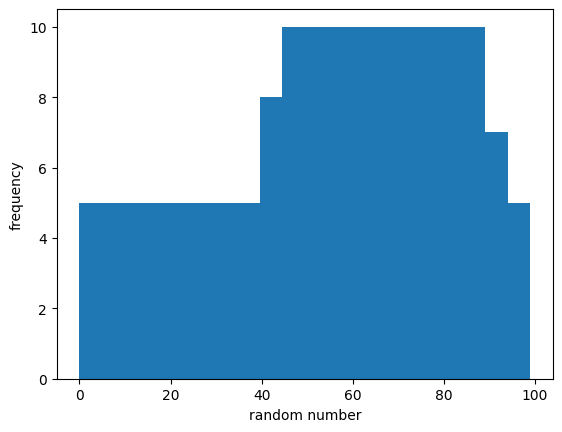

In [333]:
y = test(size=150, bins=20, multiplier=1, step=1, limit=100)
autocorrelation(y, 3)

Chi-square Test: Failed, since 590.2667 >= 30.1436


-0.18313663386836493

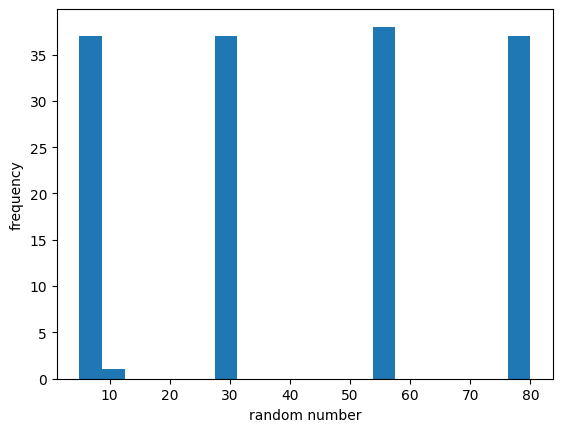

In [334]:
y = test(size=150, bins=20, multiplier=5, step=5, limit=100)
autocorrelation(y, 3)

Chi-square Test: Failed, since 150.0000 >= 30.1436


-0.2743764172335601

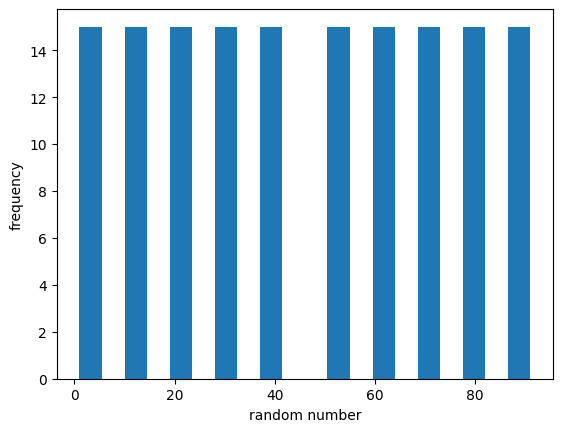

In [335]:
y = test(size=150, bins=20, multiplier=1, step=10, limit=100)
autocorrelation(y, 3)

Chi-square Test: Failed, since 1857.1600 >= 30.1436


-0.2406428822099607

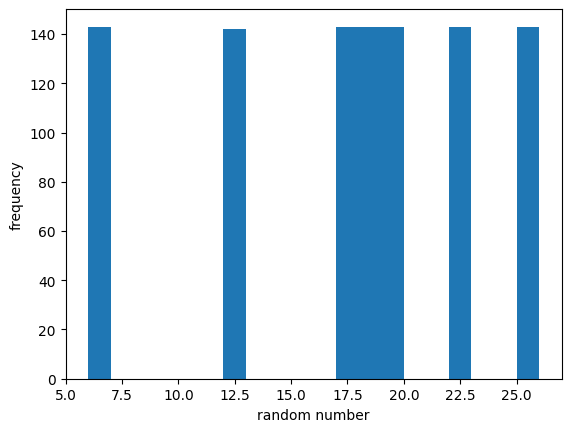

In [337]:
y = test(size=1000, bins=20, multiplier=1103515245, step=12345, limit=2^31)
autocorrelation(y, 3)